Data Analysis of Charging Brizo Batteries

In [1]:
%load_ext autoreload
%autoreload 2

from datetime import datetime
import os
import math

from utils.data.db import Database, CommonData
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt

%matplotlib widget
from pymongo import ASCENDING, MongoClient
DIR = os.path.dirname(os.path.abspath("12_20_24_charging.ipynb"))

In [2]:
DATA_FILE_PATH = os.path.join(DIR, "cached_data/12_20_raw.pkl")
#START_TIME = datetime.strptime("DD/MM/YYYY 00:00:00", "%m/%d/%Y %H:%M:%S")
#END_TIME = datetime.strptime("DD/MM/YYYY 23:59:59", "%m/%d/%Y %H:%M:%S")

try:
    #raise LookupError("uncomment if you need to reload data")
    with open(DATA_FILE_PATH, mode="rb") as file:
        data = pkl.load(file)
except (FileNotFoundError, LookupError):
    db = Database("12_20_cycling")
    data: dict[str, pd.DataFrame] = {}
    for parts in [
        db.fetch_common(name)
        for name in [
            "pack_current",
            "pack_voltage",
            "cell_voltages",
        ]
    ]:
        data.update(parts)
    with open(DATA_FILE_PATH, mode="wb") as file:
        pkl.dump(data, file)


In [3]:
#Data from 12-12-24 Charging (Unused, just here for bookeeping)
DATA_FILE_PATH = os.path.join(DIR, "cached_data/12_12_raw.pkl")
#START_TIME = datetime.strptime("DD/MM/YYYY 00:00:00", "%m/%d/%Y %H:%M:%S")
#END_TIME = datetime.strptime("DD/MM/YYYY 23:59:59", "%m/%d/%Y %H:%M:%S")

try:
    #raise LookupError("uncomment if you need to reload data")
    with open(DATA_FILE_PATH, mode="rb") as file:
       # data = pkl.load(file)
       # Uncomment above if you want to see data from 12/12/24
       data = data
except (FileNotFoundError, LookupError):
    db = Database("12_12_cycling")
    data: dict[str, pd.DataFrame] = {}
    for parts in [
        db.fetch_common(name)
        for name in [
            "pack_current",
            "pack_voltage",
            "cell_voltages",
        ]
    ]:
        data.update(parts)
    with open(DATA_FILE_PATH, mode="wb") as file:
        pkl.dump(data, file)


{'BMS_PACK_CURRENT':                  time  current
0       1734736309636    -0.06
1       1734736309817    -0.06
2       1734736309881    -0.06
3       1734736310301    -0.06
4       1734736310385    -0.06
...               ...      ...
446759  1734788050692    -0.10
446760  1734788050692    -0.10
446761  1734788050861    -0.10
446762  1734788050989    -0.10
446763  1734788051036    -0.10

[446764 rows x 2 columns], 'BMS_PACK_VOLTAGE':                  time   voltage
0       1734736309817  116.7255
1       1734736309955  116.7264
2       1734736310301  116.7239
3       1734736310386  116.7248
4       1734736310626  116.7267
...               ...       ...
244856  1734788050158  101.1692
244857  1734788050216  101.1673
244858  1734788050692  101.1697
244859  1734788050797  101.1677
244860  1734788050989  101.1661

[244861 rows x 2 columns], 'BMS_VOLTAGE1':                  time  module_1  module_2  module_3  module_4
0       1734736309817    4.1624    4.1778    4.1825    4.1898
1      

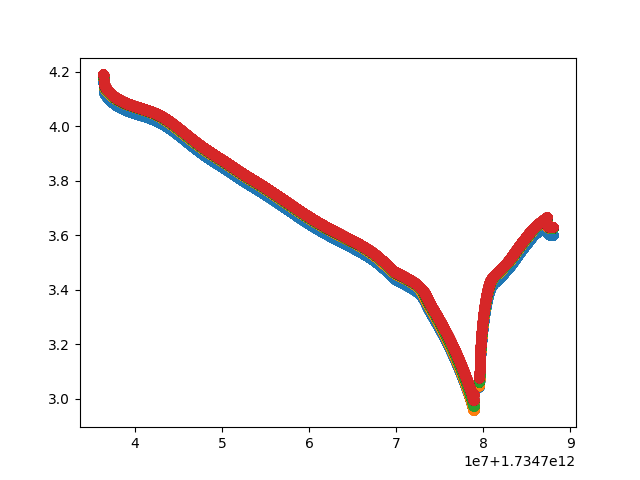

In [4]:
from utils.data.time import to_millis

# Take times (in milliseconds) where we turned current on/off
#jumps = [(1734779494684, 1734787280612)]
jumps = []
voltages = []
internal_res = []
print(data)
plt.figure()
plt.scatter(data["BMS_VOLTAGE1"]["time"],data["BMS_VOLTAGE1"]["module_1"])
plt.scatter(data["BMS_VOLTAGE1"]["time"],data["BMS_VOLTAGE1"]["module_2"])
plt.scatter(data["BMS_VOLTAGE1"]["time"],data["BMS_VOLTAGE1"]["module_3"])
plt.scatter(data["BMS_VOLTAGE1"]["time"],data["BMS_VOLTAGE1"]["module_4"])
# for each jump store the voltage change due to load
for startTime, endTime in jumps:
    avg = 0
    for i in range(7):
        start = data[f"BMS_VOLTAGE{i + 1}"]["time"].searchsorted(startTime)
        start = data[f"BMS_VOLTAGE{i + 1}"].iloc[start]
        end = data[f"BMS_VOLTAGE{i + 1}"]["time"].searchsorted(endTime)
        end = data[f"BMS_VOLTAGE{i + 1}"].iloc[end]
        diff = [
            start[f"module_{i * 4 + j + 1}"] - end[f"module_{i * 4 + j + 1}"]
            for j in range(4)
        ]
        voltages.extend(
            [
                start[f"module_{i * 4 + j + 1}"]
                if diff[j] > 0
                else end[f"module_{i * 4 + j + 1}"]
                for j in range(4)
            ]
        )
        # we were drawing at 4 amps, V = IR => R = V/I
        internal_res.extend([abs(x) / 4.0 for x in diff])
    # print("\n")
for i in range(len(voltages)):
     if internal_res[i] > 0.1:
        del voltages[i]
        del internal_res[i]
        break

In [5]:
from utils.data.process import align_df, remove_spikes, smooth_data

# takes intervals excluding non-discharging and removing the bad modules
keep_times = [
    (1734779494684, 1734787280612)
]

min_time = max([data[f"BMS_VOLTAGE{i + 1}"]["time"].iloc[0] for i in range(7)]) // 1000 + 1
max_time = min([data[f"BMS_VOLTAGE{i + 1}"]["time"].iloc[-1] for i in range(7)]) // 1000 - 1

time_uniform = np.arange(min_time * 1000, max_time * 1000, 1000)
badModules = [11,12,13,15,24,25,26]
df = pd.concat(
    [
        align_df(
            data[f"BMS_VOLTAGE{i + 1}"],
            time_uniform,
            [f"module_{i * 4 + j + 1}" for j in range(4)],
        )
        for i  in range(7)
    ], 
    axis = 1
)
df = df.drop("module_11", axis=1)
df = df.drop("module_12", axis=1)
df = df.drop("module_13", axis=1)
df = df.drop("module_15", axis=1)
df = df.drop("module_24", axis=1)
df = df.drop("module_25", axis=1)
df = df.drop("module_26", axis=1)
indices = [
    (
        np.searchsorted(time_uniform, start),
        np.searchsorted(time_uniform, end),
    )
    for start, end in keep_times
]

df = df.iloc[np.r_[*[slice(start, end) for start, end in indices]]]
df = df.reset_index(drop=True)

spikeless = remove_spikes(df, threshold=5)
modules = smooth_data(spikeless, 1)
display(modules)


,module_1,module_2,module_3,module_4,module_5,module_6,module_7,module_8,module_9,module_10,...,module_16,module_17,module_18,module_19,module_20,module_21,module_22,module_23,module_27,module_28
0,3.044211,3.048200,3.060767,3.076800,3.074833,3.056889,3.069089,3.079022,3.076500,3.065589,...,3.094122,3.089800,3.076805,3.069495,3.088310,3.082476,3.086188,3.083836,3.087888,3.054288
1,3.044419,3.048431,3.060974,3.077014,3.075083,3.057116,3.069292,3.079238,3.076722,3.065804,...,3.094343,3.090017,3.077005,3.069697,3.088522,3.082671,3.086382,3.084047,3.088103,3.054500
2,3.044627,3.048662,3.061182,3.077228,3.075334,3.057344,3.069495,3.079454,3.076946,3.066020,...,3.094564,3.090236,3.077206,3.069900,3.088735,3.082867,3.086577,3.084258,3.088319,3.054718
3,3.044836,3.048894,3.061392,3.077445,3.075585,3.057572,3.069700,3.079672,3.077170,3.066238,...,3.094786,3.090458,3.077409,3.070104,3.088949,3.083066,3.086775,3.084469,3.088535,3.054939
4,3.045048,3.049129,3.061605,3.077663,3.075836,3.057802,3.069907,3.079891,3.077397,3.066459,...,3.095010,3.090682,3.077615,3.070312,3.089165,3.083266,3.086975,3.084683,3.088754,3.055163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7781,3.638210,3.661566,3.662565,3.665760,3.667977,3.661821,3.662943,3.665990,3.668536,3.664483,...,3.669848,3.672046,3.664249,3.663118,3.663779,3.658809,3.662925,3.663229,3.665321,3.628345
7782,3.638212,3.661577,3.662576,3.665772,3.667986,3.661840,3.662957,3.665997,3.668552,3.664491,...,3.669861,3.672061,3.664263,3.663137,3.663787,3.658830,3.662943,3.663246,3.665340,3.628360
7783,3.638213,3.661587,3.662586,3.665784,3.667993,3.661858,3.662969,3.666002,3.668567,3.664498,...,3.669873,3.672075,3.664276,3.663155,3.663794,3.658850,3.662959,3.663262,3.665359,3.628374
7784,3.638212,3.661596,3.662596,3.665794,3.667999,3.661877,3.662980,3.666006,3.668581,3.664504,...,3.669884,3.672087,3.664288,3.663173,3.663800,3.658871,3.662975,3.663279,3.665377,3.628387


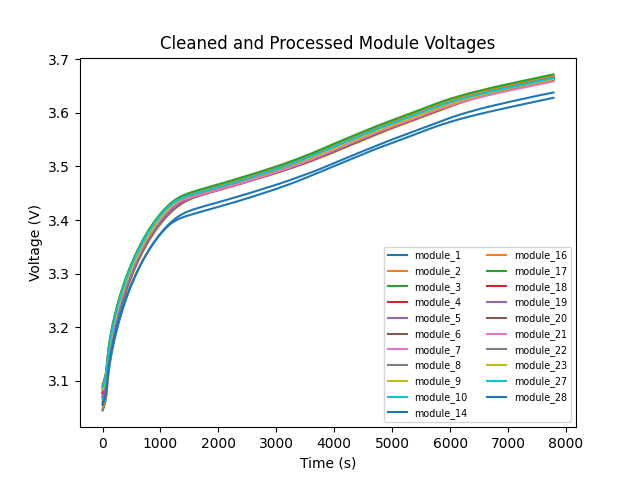

In [6]:
from utils.visualize.plotters import df_plot

# plot preprocessed data
fig = plt.figure()
ax = fig.subplots()

df_plot(ax, modules)

plt.title("Cleaned and Processed Module Voltages")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend(ncols=2, fontsize="x-small")

Text(0, 0.5, 'SOC (%)')

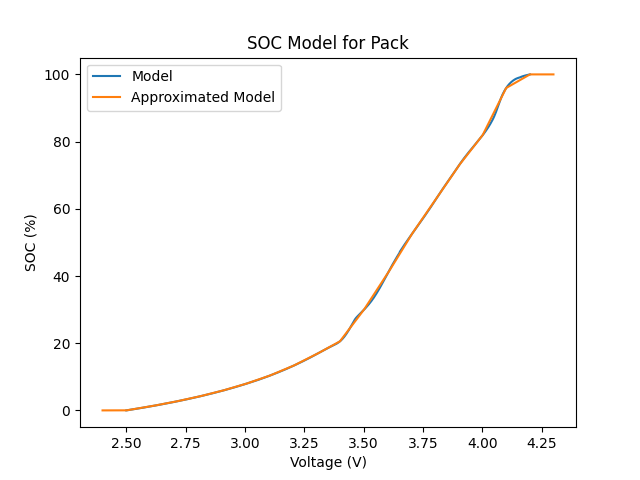

In [7]:

DATA_FILE_PATH = os.path.join(DIR, "cached_data/extrapolated.pkl")
with open(DATA_FILE_PATH, mode="rb") as file:
        extrapolated = pkl.load(file)
# averages all modules time values per voltage
avgd = extrapolated.mean(axis=1)
# turns into SOC value
soc = (1 - (avgd - avgd.iloc[-1]) / (avgd.iloc[0] - avgd.iloc[-1])) * 100
plt.figure()
plt.plot(soc.index, soc, label="Model")

# approximation for SOC based on analysis
# units in millivolts
max_vol = 4300
min_vol = 2400
step = 100

# interpolation array with padding
interp = (
    [0.0 for _ in range(int((2500 - min_vol) / step))]
    + list(soc[::step])
    + [100.0 for _ in range(int((max_vol - 4200) / step))]
)

# takes in voltage in [2.4, 4.3]
def approx_soc(voltage):
    voltage = voltage * 1000
    idx = int((voltage - min_vol) / step)
    linear_interp = (interp[idx + 1] - interp[idx]) / step
    return interp[idx] + (voltage - min_vol - idx * step) * linear_interp


sample = np.arange(2.4, 4.3, 0.001)
approx = [approx_soc(v) for v in sample]

plt.plot(sample, approx, label="Approximated Model")
plt.legend()
plt.title("SOC Model for Pack")
plt.xlabel("Voltage (V)")
plt.ylabel("SOC (%)")

In [ ]:
# calculates power dissipated
pack_power = (avgd.diff() * np.arange(2.5, 4.201, 0.001)).sum() * 4 * 28 /  -3.6e+6
print(pack_power)

-18891627.04642538
